QUESTION: Build SVM and KNN from scratch and test it on a synthetic dataset?

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from scipy.stats import mode
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class K_Nearest_Neighbors_Classifier():
    def __init__(self, k):
        self.k = k 
    
    def fit(self, X_train, Y_train):
        self.X_train = X_train
        self.Y_train = Y_train.flatten() 
        self.m , self.n = X_train.shape
    
    def predict(self, X_Test):
        self.X_test = X_Test
        self.m_test, _ = X_Test.shape
        Y_predict = np.zeros(self.m_test)


        for i in range(self.m_test):
            x = self.X_test[i] 
            neighbors = self.find_neighbors(x)
        

            Y_predict[i] = mode(neighbors, keepdims=True)[0][0]

        return Y_predict

    def find_neighbors(self, x):
        distances = np.zeros(self.m)


        for i in range(self.m):
            d = self.euclidean(x, self.X_train[i]) 
            distances[i] = d
            
        inds = distances.argsort() 
        Y_train_sorted = self.Y_train[inds]
        return Y_train_sorted[:self.k] 
            
    def euclidean(self, x, x_train):
        return np.sqrt(np.sum(np.square(x - x_train)))


In [3]:
class SVM_Classifier():
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
    
        y_transformed = np.where(y <= 0, -1, 1).flatten()
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0



        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_transformed[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_transformed[idx]))
                    self.b -= self.lr * y_transformed[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) - self.b
        return np.where(np.sign(linear_output) <= -1, 0, 1) 

KNN Classification Report
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        47
           1       0.92      0.92      0.92        53

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100


 SVM Classification Report
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        47
           1       0.89      0.91      0.90        53

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100

Final KNN Accuracy: 92.00%
Final SVM Accuracy: 89.00%


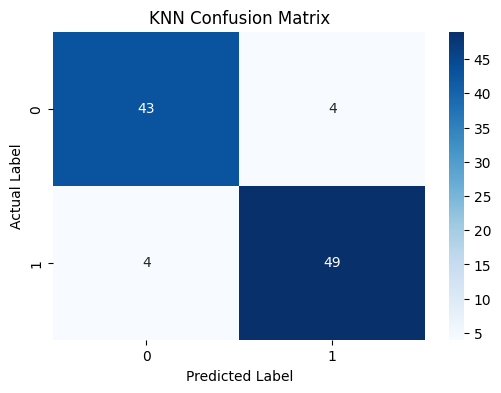

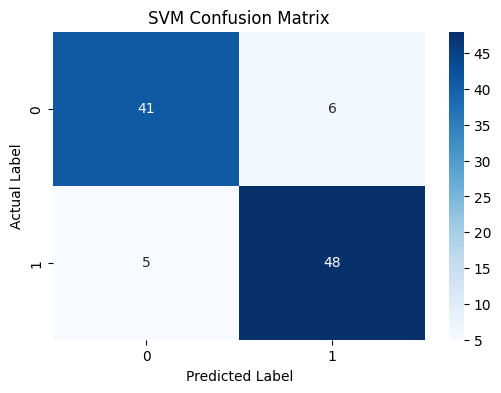

In [4]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

def main():
    X, Y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=4.0, random_state=42)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3, random_state=0)
    


    knn_model = K_Nearest_Neighbors_Classifier(k=3) 
    knn_model.fit(X_train, Y_train)
    y_pred_knn = knn_model.predict(X_test)



    svm_model = SVM_Classifier()
    svm_model.fit(X_train, Y_train)
    y_pred_svm = svm_model.predict(X_test)
    
    
    accuracy_knn = np.sum(y_pred_knn == Y_test) / len(Y_test) * 100
    accuracy_svm = np.sum(y_pred_svm == Y_test) / len(Y_test) * 100


    plot_cm(Y_test, y_pred_knn, "KNN Confusion Matrix")
    plot_cm(Y_test, y_pred_svm, "SVM Confusion Matrix")

    
    print("KNN Classification Report")
    print(classification_report(Y_test, y_pred_knn))
    
    print("\n SVM Classification Report")
    print(classification_report(Y_test, y_pred_svm))
    
    print(f"Final KNN Accuracy: {accuracy_knn:.2f}%")
    print(f"Final SVM Accuracy: {accuracy_svm:.2f}%")

if __name__ == "__main__":
    main()